## Objective 3 — Objective (Plain)

Objective:
deliveries timing of two groups is compared to metric of the delivery performance measured by average review score across year 2018

Analyse

Objective 3 — Hypothesis Testing

Research Question:
Does Late Deliveries have same average review score with Early Deliveries in deliveries performed in 2018

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import scipy.stats as stats

In [3]:
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

DATA_DIR = (
    "/kaggle/input/brazilian-ecommerce"
    if IS_KAGGLE
    else "../data/raw"
)

OUTPUT_DIR = (
    "/kaggle/working"
    if IS_KAGGLE
    else "../data/reports"
)

In [ ]:
def load_dataset(path):
    '''
    Loads a CSV file into Pandas Dataframe.
    
    args:
        path(string): File path to the csv from this file
    
    return:
        pd.DataFrame: Loaded data
    '''
    return pd.read_csv(path)
    
def measures(dataFrame):
    min = dataFrame['review_score'].min()
    max = dataFrame['review_score'].max()
    median = dataFrame['review_score'].median()
    mean = dataFrame['review_score'].mean()
    std = dataFrame['review_score'].std()
    
    return min, max, median, mean, std
    

# Datasets

In [5]:
# load the orders dataset
orders_path = f'{DATA_DIR}/olist_orders_dataset.csv'
orders_df = load_dataset(orders_path)

orders_item_path = f'{DATA_DIR}/olist_order_items_dataset.csv'
orders_item_df = load_dataset(orders_item_path)

# seller_path = f'{DATA_DIR}/olist_sellers_dataset.csv'
# seller_df = load_dataset(seller_path)

# change to review olist
review_olist_path = f"{DATA_DIR}/olist_order_reviews_dataset.csv"
review_df = load_dataset(review_olist_path)


item_order = orders_item_df.merge(orders_df, on='order_id')
item_review_order_df = item_order.merge(review_df, on='order_id')
item_review_order_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,97ca439bc427b48bc1cd7177abe71365,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,7b07bacd811c4117b742569b04ce3580,4,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,0c5b33dea94867d1ac402749e5438e8b,5,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,f4028d019cb58564807486a6aaf33817,4,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,940144190dcba6351888cafa43f3a3a5,5,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112367,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18 00:00:00,9185f849f32d82e216a4e025e0c50f5c,5,NaN,NaN,2018-05-11 00:00:00,2018-05-14 12:53:47
112368,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01 00:00:00,be803f6a93d64719fd685c1cc610918a,5,NaN,NaN,2018-07-24 00:00:00,2018-07-25 09:25:29
112369,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10 00:00:00,dbdd81cd59a1a9f94a10a990b4d48dce,5,NaN,NaN,2017-10-29 00:00:00,2017-10-29 21:33:52
112370,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25 00:00:00,fba117c9ac40d41ca7be54741f471303,5,NaN,Recebi o produto antes do prazo e corretamente.,2017-08-17 00:00:00,2017-08-18 12:24:05


In [6]:
item_review_order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112372 entries, 0 to 112371
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112372 non-null  object 
 1   order_item_id                  112372 non-null  int64  
 2   product_id                     112372 non-null  object 
 3   seller_id                      112372 non-null  object 
 4   shipping_limit_date            112372 non-null  object 
 5   price                          112372 non-null  float64
 6   freight_value                  112372 non-null  float64
 7   customer_id                    112372 non-null  object 
 8   order_status                   112372 non-null  object 
 9   order_purchase_timestamp       112372 non-null  object 
 10  order_approved_at              112357 non-null  object 
 11  order_delivered_carrier_date   111188 non-null  object 
 12  order_delivered_customer_date 

### Insight

bahwa terdapat beberapa missing data pada kolom-kolom date tertentu, yang menunjukan bahwa data perlu di lakukan filtering dan data cleaning sebelum dilakukan analisa


# Data Cleaning

In [16]:
#check for na, then isolate them
na_item_seller_order_df = item_review_order_df[item_review_order_df.isnull().any(axis=1)]

#convert columns
item_review_order_df['order_purchase_timestamp'] = pd.to_datetime(item_review_order_df['order_purchase_timestamp'], errors='coerce')
item_review_order_df['order_estimated_delivery_date'] = pd.to_datetime(item_review_order_df['order_estimated_delivery_date'], errors='coerce')
item_review_order_df['order_delivered_customer_date'] = pd.to_datetime(item_review_order_df['order_delivered_customer_date'], errors='coerce')

cleaned_item_review_order_df = item_review_order_df.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date','order_purchase_timestamp'])

# check for null or NaN in column review_score
cleaned_item_review_order_df = cleaned_item_review_order_df.dropna(subset=['review_score'])

cleaned_item_review_order_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,97ca439bc427b48bc1cd7177abe71365,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,7b07bacd811c4117b742569b04ce3580,4,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,0c5b33dea94867d1ac402749e5438e8b,5,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,f4028d019cb58564807486a6aaf33817,4,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,940144190dcba6351888cafa43f3a3a5,5,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112367,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,9185f849f32d82e216a4e025e0c50f5c,5,NaN,NaN,2018-05-11 00:00:00,2018-05-14 12:53:47
112368,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,be803f6a93d64719fd685c1cc610918a,5,NaN,NaN,2018-07-24 00:00:00,2018-07-25 09:25:29
112369,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10,dbdd81cd59a1a9f94a10a990b4d48dce,5,NaN,NaN,2017-10-29 00:00:00,2017-10-29 21:33:52
112370,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25,fba117c9ac40d41ca7be54741f471303,5,NaN,Recebi o produto antes do prazo e corretamente.,2017-08-17 00:00:00,2017-08-18 12:24:05


# Data Filtering

criteria:

- data form year 2018
- order status must be 'delivered'
- also do data validations on the date column
- take only `late` orders

In [11]:
# take only 2018 data 
cleaned_item_seller_order_df = cleaned_item_review_order_df[pd.to_datetime(cleaned_item_review_order_df['order_purchase_timestamp']).dt.year == 2018].copy() 

# take only delivered orders
cleaned_item_review_order_df = cleaned_item_review_order_df[cleaned_item_review_order_df['order_status'] == 'delivered']
cleaned_item_review_order_df


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_delay_days,delivery_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-20 23:43:48,2017-09-29,97ca439bc427b48bc1cd7177abe71365,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,-9,early
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-12 16:04:24,2017-05-15,7b07bacd811c4117b742569b04ce3580,4,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13,-3,early
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-01-22 13:19:16,2018-02-05,0c5b33dea94867d1ac402749e5438e8b,5,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31,-14,early
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-14 13:32:39,2018-08-20,f4028d019cb58564807486a6aaf33817,4,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01,-6,early
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-01 16:42:31,2017-03-17,940144190dcba6351888cafa43f3a3a5,5,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59,-16,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112367,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,2018-05-10 22:56:40,2018-05-18,9185f849f32d82e216a4e025e0c50f5c,5,NaN,NaN,2018-05-11 00:00:00,2018-05-14 12:53:47,-8,early
112368,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,2018-07-23 20:31:55,2018-08-01,be803f6a93d64719fd685c1cc610918a,5,NaN,NaN,2018-07-24 00:00:00,2018-07-25 09:25:29,-9,early
112369,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,2017-10-28 12:22:22,2017-11-10,dbdd81cd59a1a9f94a10a990b4d48dce,5,NaN,NaN,2017-10-29 00:00:00,2017-10-29 21:33:52,-13,early
112370,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,2017-08-16 21:59:40,2017-08-25,fba117c9ac40d41ca7be54741f471303,5,NaN,Recebi o produto antes do prazo e corretamente.,2017-08-17 00:00:00,2017-08-18 12:24:05,-9,early


In [13]:
# create new column `delivery_delay_days`
cleaned_item_review_order_df['delivery_delay_days'] = (cleaned_item_review_order_df['order_delivered_customer_date'] - cleaned_item_review_order_df['order_estimated_delivery_date']).dt.days

# take only late orders
# cleaned_item_seller_order_df = cleaned_item_seller_order_df[cleaned_item_seller_order_df['delivery_delay_days'] > 0]
cleaned_item_review_order_df['delivery_category'] = 'early'
cleaned_item_review_order_df.loc[
    cleaned_item_review_order_df['delivery_delay_days'].between(0,1),
    'delivery_category'
] = 'on-time'
cleaned_item_review_order_df.loc[
    cleaned_item_review_order_df['delivery_delay_days'] > 1,
    'delivery_category'
] = 'late'

late_review_deliveries = cleaned_item_review_order_df[cleaned_item_review_order_df['delivery_category'] == 'late'].copy()
early_review_deliveries = cleaned_item_review_order_df[cleaned_item_review_order_df['delivery_category'] == 'early'].copy()


In [14]:
late_review_deliveries

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_delay_days,delivery_category
21,000e906b789b55f64edcb1f84030f90d,1,57d79905de06d8897872c551bfd09358,ea8482cd71df3c1969d7b9473ff13abc,2017-11-27 19:09:02,21.99,11.85,6a3b2fc9f270df258605e22bef19fd88,delivered,2017-11-21 18:54:23,...,2017-12-09 17:27:23,2017-12-07,a5fb93d6a9e707bd84c07da74e8d79fd,3,NaN,NaN,2017-12-09 00:00:00,2017-12-11 09:55:13,2,late
36,0017afd5076e074a48f1f1a4c7bac9c5,1,fe59a1e006df3ac42bf0ceb876d70969,25c5c91f63607446a97b143d2d535d31,2017-04-24 22:25:19,809.10,44.29,8085a9af46f619bc25966f151a362b0d,delivered,2017-04-06 22:16:10,...,2017-05-23 08:32:07,2017-05-19,f7bbac6b6901d7636435ea406a856e34,1,NaN,NaN,2017-05-21 00:00:00,2017-05-21 11:30:42,4,late
44,001c85b5f68d2be0cb0797afc9e8ce9a,1,84f456958365164420cfc80fbe4c7fab,4a3ca9315b744ce9f8e9374361493884,2017-11-29 22:38:47,99.00,13.71,48ed31e735f1c420ed6ca3637b7c744d,delivered,2017-11-24 19:19:18,...,2017-12-22 18:37:40,2017-12-14,bef8f895661652ee0f5dbc2626864df3,2,NaN,NaN,2017-12-16 00:00:00,2017-12-20 21:03:14,8,late
45,001d8f0e34a38c37f7dba2a37d4eba8b,1,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78,d987da9fb4086ab7c2c0f83963cd6722,delivered,2017-05-14 17:19:44,...,2017-05-26 13:14:50,2017-05-24,51ebb8fede4fbe6126f9f85ebdd23166,1,NaN,Entrega prometida 24/05/17. Dia 26/05/17 não h...,2017-05-26 00:00:00,2017-05-26 20:19:13,2,late
46,001d8f0e34a38c37f7dba2a37d4eba8b,2,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78,d987da9fb4086ab7c2c0f83963cd6722,delivered,2017-05-14 17:19:44,...,2017-05-26 13:14:50,2017-05-24,51ebb8fede4fbe6126f9f85ebdd23166,1,NaN,Entrega prometida 24/05/17. Dia 26/05/17 não h...,2017-05-26 00:00:00,2017-05-26 20:19:13,2,late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112338,ffecd5a79a0084f6a592288c67e3c298,2,50fd2b788dc166edd20512370dac54df,8b321bb669392f5163d04c59e235e066,2018-03-05 20:15:27,21.90,15.79,8afa5a415d65a08e3a68b1d7f9ddd8a5,delivered,2018-02-27 20:00:25,...,2018-03-29 14:37:05,2018-03-22,63f01eff060a94c562615719b3cc7e8c,2,NaN,NaN,2018-03-24 00:00:00,2018-03-24 15:21:09,7,late
112339,ffecd5a79a0084f6a592288c67e3c298,3,50fd2b788dc166edd20512370dac54df,8b321bb669392f5163d04c59e235e066,2018-03-05 20:15:27,21.90,15.79,8afa5a415d65a08e3a68b1d7f9ddd8a5,delivered,2018-02-27 20:00:25,...,2018-03-29 14:37:05,2018-03-22,63f01eff060a94c562615719b3cc7e8c,2,NaN,NaN,2018-03-24 00:00:00,2018-03-24 15:21:09,7,late
112345,ffefb169ddf34cecc0622a6d3cc387f8,1,601a360bd2a916ecef0e88de72a6531a,7a67c85e85bb2ce8582c35f2203ad736,2017-07-06 19:35:09,129.99,12.11,b607e077c8906af72c47a8554a26bc05,delivered,2017-07-02 19:22:03,...,2017-07-19 16:36:31,2017-07-14,85ebc8f24b564ee8b85dbe209a5892e1,1,NaN,NaN,2017-07-16 00:00:00,2017-07-18 18:28:10,5,late
112348,fff2cdc825f9fc0ba3c04227cfa02303,1,044f05bc9de36e8a693a83e4bc79dd0d,ea8482cd71df3c1969d7b9473ff13abc,2018-02-08 02:52:42,24.99,25.63,9c18c06ccf9b2fafcc5f956c5b145212,delivered,2018-02-02 10:28:41,...,2018-03-12 17:08:53,2018-03-06,cf0b8c06ba024a8a8d3f2ac51fcd99f4,2,NaN,NaN,2018-03-09 00:00:00,2018-04-23 17:52:49,6,late


In [15]:
early_review_deliveries

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_delay_days,delivery_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-20 23:43:48,2017-09-29,97ca439bc427b48bc1cd7177abe71365,5,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21 00:00:00,2017-09-22 10:57:03,-9,early
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-12 16:04:24,2017-05-15,7b07bacd811c4117b742569b04ce3580,4,NaN,NaN,2017-05-13 00:00:00,2017-05-15 11:34:13,-3,early
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-01-22 13:19:16,2018-02-05,0c5b33dea94867d1ac402749e5438e8b,5,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23 00:00:00,2018-01-23 16:06:31,-14,early
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-14 13:32:39,2018-08-20,f4028d019cb58564807486a6aaf33817,4,NaN,NaN,2018-08-15 00:00:00,2018-08-15 16:39:01,-6,early
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-01 16:42:31,2017-03-17,940144190dcba6351888cafa43f3a3a5,5,NaN,Gostei pois veio no prazo determinado .,2017-03-02 00:00:00,2017-03-03 10:54:59,-16,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112367,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,2018-05-10 22:56:40,2018-05-18,9185f849f32d82e216a4e025e0c50f5c,5,NaN,NaN,2018-05-11 00:00:00,2018-05-14 12:53:47,-8,early
112368,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,2018-07-23 20:31:55,2018-08-01,be803f6a93d64719fd685c1cc610918a,5,NaN,NaN,2018-07-24 00:00:00,2018-07-25 09:25:29,-9,early
112369,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,2017-10-28 12:22:22,2017-11-10,dbdd81cd59a1a9f94a10a990b4d48dce,5,NaN,NaN,2017-10-29 00:00:00,2017-10-29 21:33:52,-13,early
112370,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,2017-08-16 21:59:40,2017-08-25,fba117c9ac40d41ca7be54741f471303,5,NaN,Recebi o produto antes do prazo e corretamente.,2017-08-17 00:00:00,2017-08-18 12:24:05,-9,early


In [ ]:
# seller_late_count = cleaned_item_seller_order_df
late_review_deliveries_min,late_review_deliveries_max, late_review_deliveries_median, late_review_deliveries_mean, late_review_deliveries_std = measures(late_review_deliveries)
early_review_deliveries_min,early_review_deliveries_max, early_review_deliveries_median, early_review_deliveries_mean, early_review_deliveries_std = measures(early_review_deliveries)

print(f"""
      mean = {early_review_deliveries_mean} | {late_review_deliveries_mean} | Difference = {late_review_deliveries_mean - early_review_deliveries_mean}
      median = {early_review_deliveries_median} | {late_review_deliveries_median} | Difference = {late_review_deliveries_median - early_review_deliveries_median}
      min = {early_review_deliveries_min} | {late_review_deliveries_min}
      max = {early_review_deliveries_max} | {late_review_deliveries_max}
      std = {early_review_deliveries_std} | {late_review_deliveries_std}
      """)


      mean = 4.210587017595741 | 2.041282175813502 | Difference = -2.1693048417822394
      median = 5.0 | 1.0 | Difference = -4.0
      min = 1 | 1
      max = 5 | 5
      std = 1.2336315605748782 | 1.4756482419591919
      


# HISTOGRAM

<Axes: >

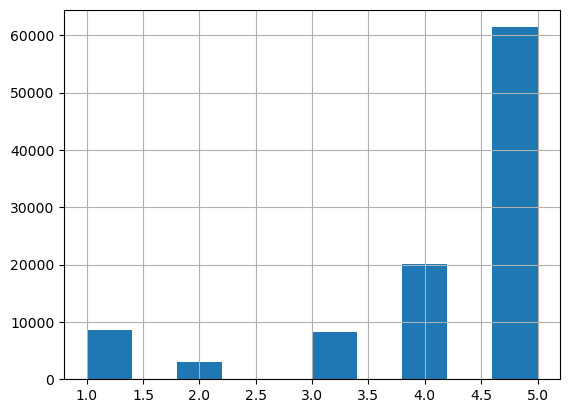

In [24]:
early_review_deliveries['review_score'].hist()

<Axes: >

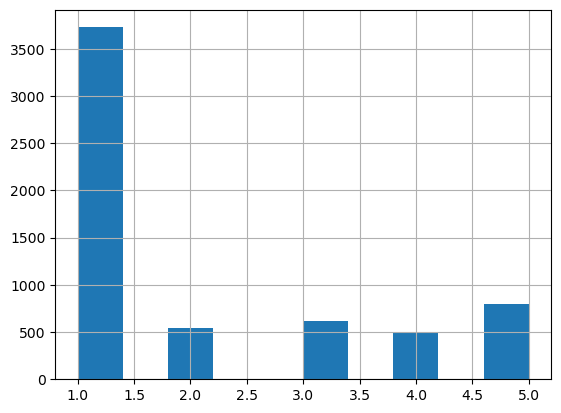

In [25]:
late_review_deliveries['review_score'].hist()

We'll be using man whiteney u test because:
1. the distribution is skewed
2. we're looking for typical values and not outlier
3. test data is 2 independent sample group (Late deliveries average review score vs Early Deliveries average Review Score)

Null Hypothesis (H₀)

Late deliveries has relative same average review score with Early Deliveries


Alternative Hypothesis (H₁)

Late deliveries has relative different average review score with Early Deliveries

In [26]:
statistic,p_value = stats.ttest_ind(early_review_deliveries['review_score'], late_review_deliveries['review_score'])

alpha = 0.05
print(f"""
      statistic = {statistic}
      p-val = {p_value}
      is it less than {alpha} = {p_value < alpha}
      """)


      statistic = 132.55159797991178
      p-val = 0.0
      is it less than 0.05 = True
      


# Insight

based on the test, we reject the null hypothesis (H0)

this indicates there's evidence of statistically different review scores between Late Deliveries and Early Deliveries.

from business perspective, delivery timing maybe associated to customer review outcomes.

nonetheless, this result does not mean which group is better than the other nor does it imply causation